# Road Safety in Great Britain — Data Visualisation Project
### UK Department for Transport Road Casualty Statistics, January–June 2025 (provisional)

**Module:** LDS7004M Data Visualization  

This notebook imports, cleans and explores three linked road-safety tables (collisions, casualties and vehicles).
The goal is to turn raw STATS19 police-reported data into clear visual stories about **when and where** road
collisions happen and **who** gets hurt. Each section has a short note explaining what the code does and what the
chart shows.

**How to run:** put this notebook in the same folder as the three CSV files and run the cells top to bottom.
You need `pandas`, `numpy`, `matplotlib` and `seaborn` installed (`pip install pandas numpy matplotlib seaborn`).

## 1. Import the libraries and set a clean house style
I use pandas/numpy for the data work and matplotlib/seaborn for the plots. I set one colour theme up front so every chart looks consistent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl   # needed to read the DfT data guide

sns.set_theme(style="whitegrid", font_scale=1.05)
NAVY, RED, AMBER, TEAL, GREY = "#1f3b57", "#c0392b", "#e0a106", "#2a9d8f", "#6c757d"
# one colour per severity, used in every chart so the reader learns it once
SEV = {"Fatal":"#b2182b", "Serious":"#ef8a62", "Slight":"#67a9cf"}
sev_order = ["Slight", "Serious", "Fatal"]
plt.rcParams.update({"figure.dpi":110, "axes.titleweight":"bold"})

## 2. Import the three datasets
The data comes as three tables that all share a `collision_index` key, so they can be linked together.

In [2]:
collision = pd.read_csv("dft-road-casualty-statistics-collision-provisional-2025 (1).csv", low_memory=False)
casualty  = pd.read_csv("dft-road-casualty-statistics-casualty-provisional-2025.csv", low_memory=False)
vehicle   = pd.read_csv("dft-road-casualty-statistics-vehicle-provisional-2025.csv", low_memory=False)

print("Collisions:", collision.shape)
print("Casualties:", casualty.shape)
print("Vehicles:  ", vehicle.shape)
collision.head(3)

Collisions: (48472, 44)
Casualties: (60991, 23)
Vehicles:   (87805, 32)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2025010551784,2025,010551784,528234.0,185607.0,-0.15174,51.55478,1,3,3,...,0,0,1,1,-1,E01000886,-1,0,0.0,1.0
1,2025010551786,2025,010551786,529585.0,178570.0,-0.13485,51.49124,1,3,2,...,0,0,1,3,-1,E01004747,-1,0,0.0,1.0
2,2025010551792,2025,010551792,524767.0,187961.0,-0.20089,51.57671,1,3,5,...,0,0,1,1,-1,E01000216,-1,0,0.0,1.0


## 3. Data cleaning and preparation
The DfT stores everything as numbers (codes), e.g. severity `1 = Fatal`. Missing answers are stored as `-1`.
Four cleaning jobs are needed:
1. **Build a lookup dictionary** from the official DfT data guide (Excel file) — only the columns relevant to this project's research questions (when/where, who, and why) were selected from the guide's 1,821 rows.
2. **Decode** the number codes into readable labels using that lookup.
3. **Handle missing/invalid values** — treat `-1` as NaN so it does not pollute the charts.
4. **Identify and handle outliers** — check numeric columns for values that are implausible or extreme.

### Why these columns?
The columns kept in the lookup were chosen to answer three questions:
- **When/where:** `day_of_week`, `light_conditions`, `weather_conditions`, `road_surface_conditions`, `road_type`, `urban_or_rural_area`, `collision_severity`
- **Who:** `casualty_class`, `casualty_type`, `casualty_severity`, `sex_of_casualty`, `age_band_of_casualty`
- **Why (contributing factors):** `vehicle_type`, `propulsion_code`, `journey_purpose_of_driver`, `age_band_of_driver`, `junction_detail`, `carriageway_hazards`

Fields with hundreds of codes (e.g. `police_force`, `local_authority_district`) were excluded — the geographic map uses raw latitude/longitude instead.

In [3]:
# --- Build lookup dictionary from the official DfT data guide ---
def build_lookup(guide_path):
    """Read the DfT Excel data guide and return a nested dict:
       { field_name: { code_int: label_str } }
       Only fields used in this analysis are kept."""
    KEEP = {
        'collision_severity', 'day_of_week', 'light_conditions', 'weather_conditions',
        'road_surface_conditions', 'road_type', 'urban_or_rural_area',
        'junction_detail', 'junction_control', 'carriageway_hazards',
        'casualty_severity', 'casualty_class', 'casualty_type',
        'sex_of_casualty', 'age_band_of_casualty',
        'vehicle_type', 'sex_of_driver', 'age_band_of_driver',
        'vehicle_manoeuvre', 'journey_purpose_of_driver', 'propulsion_code',
    }
    wb = openpyxl.load_workbook(guide_path)
    ws = wb['2024_code_list']
    lookup = {}
    for row in ws.iter_rows(min_row=2, values_only=True):
        table, field, code, label, note = row
        if field in KEEP and code is not None and label is not None:
            lookup.setdefault(field, {})[int(code)] = label
    return lookup

GUIDE = "dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024 (2).xlsx"
LOOKUP = build_lookup(GUIDE)
print(f"Loaded {len(LOOKUP)} field lookups from data guide.")
print("Fields decoded:", sorted(LOOKUP.keys()))

In [4]:
# Helper: replace -1 with NaN then map codes to labels
def decode_df(df):
    df = df.replace(-1, np.nan)
    for col in df.columns:
        if col in LOOKUP:
            df[col] = df[col].map(LOOKUP[col]).fillna(df[col])
    return df

# --- Decode the COLLISION table ---
collision = decode_df(collision)
collision["date"]  = pd.to_datetime(collision["date"], format="%d/%m/%Y")
collision["month"] = collision["date"].dt.month_name().str[:3]
collision["hour"]  = pd.to_numeric(collision["time"].str[:2], errors="coerce")
collision["Severity"] = collision["collision_severity"]   # already decoded
collision["DOW"]      = collision["day_of_week"]
collision["Light"]    = collision["light_conditions"]
collision["Weather"]  = collision["weather_conditions"]
collision["Surface"]  = collision["road_surface_conditions"]
collision["Urban"]    = collision["urban_or_rural_area"]
collision["speed"]    = pd.to_numeric(collision["speed_limit"], errors="coerce")

# --- Decode the CASUALTY table ---
casualty = decode_df(casualty)
casualty["Severity"] = casualty["casualty_severity"]
casualty["Class"]    = casualty["casualty_class"]
casualty["Sex"]      = casualty["sex_of_casualty"]
casualty["AgeBand"]  = casualty["age_band_of_casualty"]
casualty["Type"]     = casualty["casualty_type"].fillna("Other/Unknown")
casualty["IMD"]      = pd.to_numeric(casualty["casualty_imd_decile"], errors="coerce")

# --- Decode the VEHICLE table ---
vehicle = decode_df(vehicle)
vehicle["VType"] = vehicle["vehicle_type"].fillna("Other/Unknown")
vehicle["DSex"]  = vehicle["sex_of_driver"]

print("Decoding done. Example:")
collision[["date","Severity","DOW","Weather","Urban","speed"]].head()

Decoding done. Example:


,date,Severity,DOW,Weather,Urban,speed
0,2025-01-01,Slight,Wed,Fine,Urban,20.0
1,2025-01-01,Slight,Wed,Fine,Urban,20.0
2,2025-01-01,Slight,Wed,Fine + winds,Urban,30.0
3,2025-01-01,Serious,Wed,Fine + winds,Urban,20.0
4,2025-01-01,Serious,Wed,Fine + winds,Urban,20.0


### 3.1 Missing-value check
Before plotting I check how much data is missing in the key columns. A `-1` code (or a blank) means the police
form was not completed for that field. One column, `age_of_vehicle`, is `-1` for **every** row, so it carries no
information and is dropped.

In [5]:
key_cols = ["speed_limit","light_conditions","weather_conditions","road_surface_conditions"]
missing = {c: int((collision[c]==-1).sum()) for c in key_cols}
print("Missing (-1) values in collision table:", missing)
print("age_of_vehicle is -1 for", round(100*(vehicle['age_of_vehicle']==-1).mean(),1), "% of rows -> drop it")
vehicle = vehicle.drop(columns=["age_of_vehicle"])

Missing (-1) values in collision table: {'speed_limit': 185, 'light_conditions': 307, 'weather_conditions': 422, 'road_surface_conditions': 922}
age_of_vehicle is -1 for 100.0 % of rows -> drop it


### 3.2 Outlier detection
Numeric columns are checked for implausible values. Speed limit, age, and location are the main candidates.

In [ ]:
# --- Outlier detection on key numeric columns ---

# Speed limit: valid values are 20, 30, 40, 50, 60, 70 mph
valid_speeds = [20, 30, 40, 50, 60, 70]
bad_speed = collision['speed'].dropna()
bad_speed = bad_speed[~bad_speed.isin(valid_speeds)]
print(f"Unusual speed limit values: {bad_speed.value_counts().to_dict()}")

# Age of casualty: flag anything over 100 as implausible
old_cas = casualty[casualty['age_of_casualty'] > 100]
print(f"Casualties with age > 100: {len(old_cas)}")

# Location outliers: collisions outside Great Britain bounding box
out_of_bounds = collision[
    ~(collision['latitude'].between(49, 61)) |
    ~(collision['longitude'].between(-8, 2))
]
print(f"Collisions outside GB bounding box: {len(out_of_bounds)}")

# Number of vehicles/casualties: check for extreme values
print(f"Max vehicles in one collision: {collision['number_of_vehicles'].max()}")
print(f"Max casualties in one collision: {collision['number_of_casualties'].max()}")

# Summary stats for key numeric columns
collision[['speed','number_of_vehicles','number_of_casualties']].describe().round(2)

## 4. Key headline numbers
A quick summary of the scale of the data before we visualise it.

In [6]:
print("Period      :", collision['date'].min().date(), "to", collision['date'].max().date())
print("Collisions  :", f"{len(collision):,}")
print("Casualties  :", f"{len(casualty):,}")
print("Vehicles    :", f"{len(vehicle):,}")
sv = collision['Severity'].value_counts()
print("Fatal/Serious/Slight:", sv.get('Fatal',0), "/", sv.get('Serious',0), "/", sv.get('Slight',0))
print("Killed or seriously injured (KSI) share:",
      round(100*(collision['Severity'].isin(['Fatal','Serious'])).mean(),1), "%")

Period      : 2025-01-01 to 2025-06-30
Collisions  : 48,472
Casualties  : 60,991
Vehicles    : 87,805
Fatal/Serious/Slight: 696 / 11964 / 35812
Killed or seriously injured (KSI) share: 26.1 %


## 5. Visualisations
The story is told in two parts: **(A) when and where** collisions happen, and **(B) who** is hurt and how badly.

### Fig 1 — Overall severity split
A donut chart shows most collisions are 'slight', but a serious minority are fatal or serious. This sets the scene.

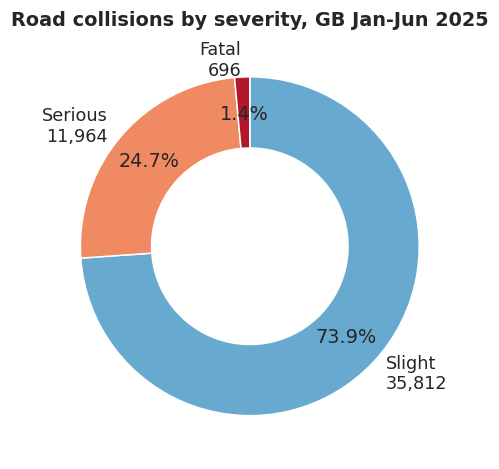

In [7]:
vals = [sv['Slight'], sv['Serious'], sv['Fatal']]
labs = [f"Slight\n{sv['Slight']:,}", f"Serious\n{sv['Serious']:,}", f"Fatal\n{sv['Fatal']:,}"]
plt.figure(figsize=(6,5))
plt.pie(vals, labels=labs, colors=[SEV['Slight'],SEV['Serious'],SEV['Fatal']],
        autopct=lambda p:f"{p:.1f}%", startangle=90, counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor='w'), pctdistance=0.78)
plt.title("Road collisions by severity, GB Jan-Jun 2025"); plt.show()

### Fig 2 — Day of week
A bar chart of collisions by weekday. Weekdays are higher than weekends because of commuter traffic.

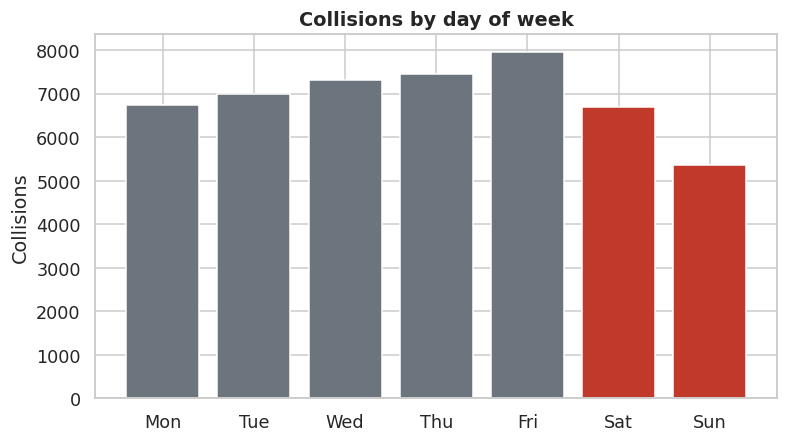

In [8]:
plt.figure(figsize=(8,4.3))
dow = collision['DOW'].value_counts().reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.bar(dow.index, dow.values, color=[GREY]*5+[RED,RED])
plt.title("Collisions by day of week"); plt.ylabel("Collisions"); plt.show()

### Fig 3 — Hour of day & the day×hour heatmap
The line shows two clear rush-hour peaks (8am, 5pm). The heatmap makes it obvious these peaks are a **weekday** pattern, while weekend collisions spread into the afternoon/night.

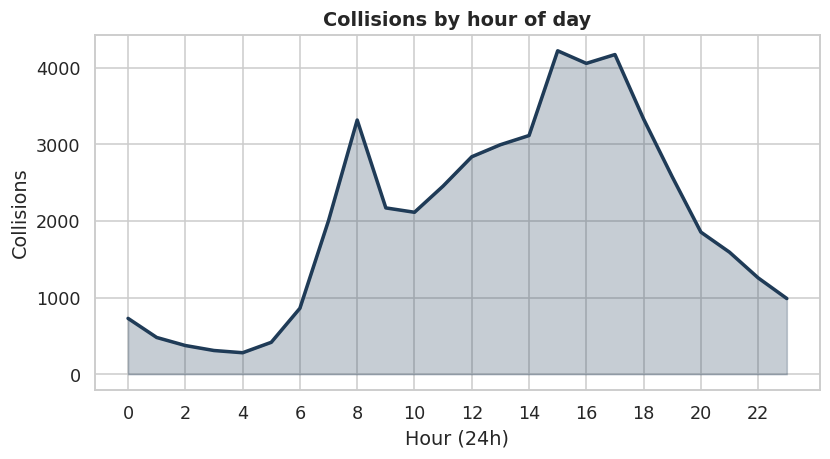

In [9]:
plt.figure(figsize=(8.5,4.2))
hr = collision.dropna(subset=['hour']).groupby('hour').size()
plt.fill_between(hr.index, hr.values, color=NAVY, alpha=0.25)
plt.plot(hr.index, hr.values, color=NAVY, lw=2.3)
plt.title("Collisions by hour of day"); plt.xlabel("Hour (24h)"); plt.ylabel("Collisions")
plt.xticks(range(0,24,2)); plt.show()

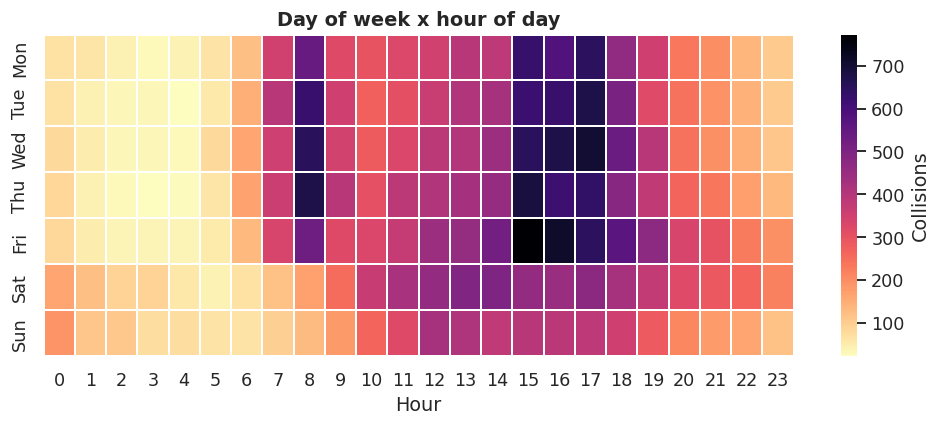

In [10]:
piv = (collision.dropna(subset=['hour'])
       .pivot_table(index='DOW', columns='hour', values='collision_index', aggfunc='count')
       .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
plt.figure(figsize=(11,3.8))
sns.heatmap(piv, cmap='magma_r', linewidths=.3, linecolor='white', cbar_kws={'label':'Collisions'})
plt.title("Day of week x hour of day"); plt.xlabel("Hour"); plt.ylabel(""); plt.show()

### Fig 4 — Weather and severity
Stacked bars show the **share** of each severity within each weather type. Most crashes happen in fine weather (because that is when most driving happens), but fog and snow show a higher serious/fatal share.

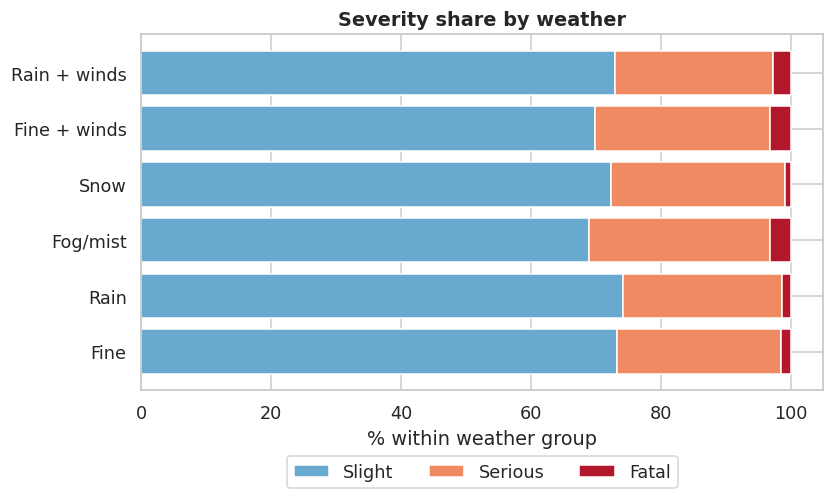

In [11]:
d = collision[collision['Weather'].notna()]
order = ['Fine','Rain','Fog/mist','Snow','Fine + winds','Rain + winds']
ct = (pd.crosstab(d['Weather'], d['Severity'], normalize='index')[sev_order]*100).reindex(order).dropna()
fig, ax = plt.subplots(figsize=(8,4.2)); bottom=np.zeros(len(ct))
for s in sev_order:
    ax.barh(ct.index, ct[s], left=bottom, color=SEV[s], label=s); bottom+=ct[s].values
ax.set_xlabel("% within weather group"); ax.set_title("Severity share by weather")
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5,-0.3)); plt.show()

### Fig 5 — Speed limit and the serious/fatal share
For each speed limit I calculate the % of collisions that are killed-or-seriously-injured (KSI). The share climbs with speed and peaks on 60 mph rural roads.

/sessions/vibrant-determined-galileo/tmp/ipykernel_13/977305096.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate = sp.groupby('speed').apply(lambda g: 100*g['Severity'].isin(['Fatal','Serious']).mean())


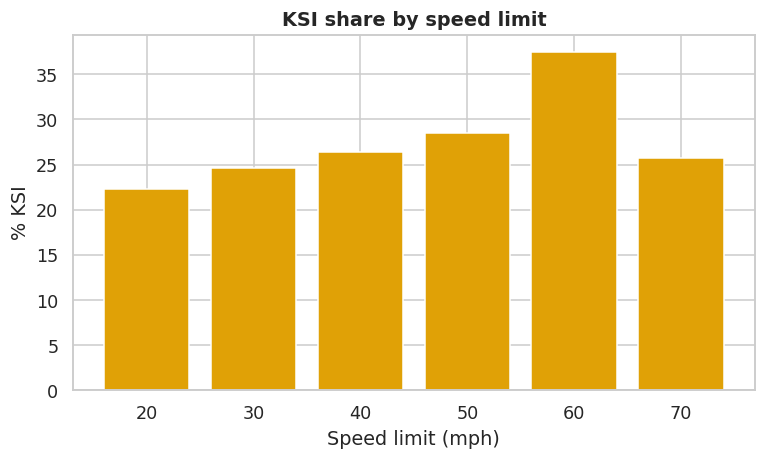

In [12]:
sp = collision.dropna(subset=['speed'])
rate = sp.groupby('speed').apply(lambda g: 100*g['Severity'].isin(['Fatal','Serious']).mean())
plt.figure(figsize=(8,4.2))
plt.bar(rate.index.astype(int).astype(str), rate.values, color=AMBER, edgecolor='white')
plt.ylabel("% KSI"); plt.xlabel("Speed limit (mph)"); plt.title("KSI share by speed limit"); plt.show()

### Fig 6 — Urban vs rural
Rural roads have far fewer collisions but a much higher **fatal** share — higher speeds and slower emergency access.

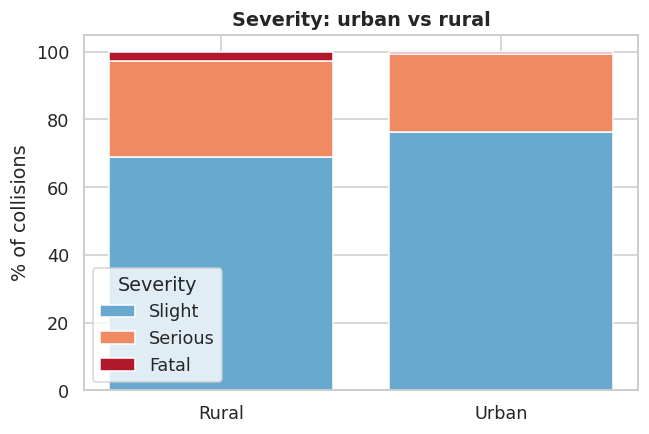

In [13]:
ur = (pd.crosstab(collision[collision['Urban'].isin(['Urban','Rural'])]['Urban'],
                  collision['Severity'], normalize='index')[sev_order]*100)
plt.figure(figsize=(6.5,4.2)); bottom=np.zeros(len(ur))
for s in sev_order:
    plt.bar(ur.index, ur[s], bottom=bottom, color=SEV[s], label=s); bottom+=ur[s].values
plt.ylabel("% of collisions"); plt.title("Severity: urban vs rural"); plt.legend(title="Severity"); plt.show()

### Fig 7 — Where collisions cluster (map)
Using latitude/longitude, a hexbin map shows the geography of GB collisions. Big cities — especially London — light up. A log colour scale stops London from washing out everywhere else.

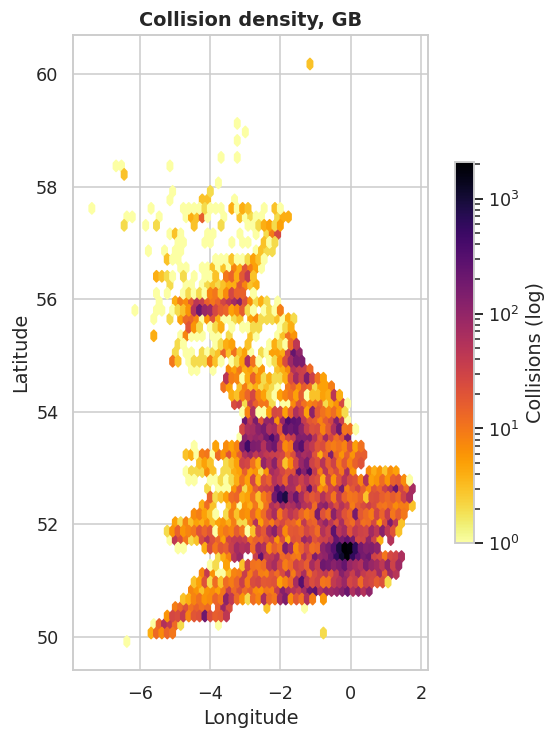

In [14]:
g = collision.dropna(subset=['latitude','longitude'])
g = g[(g['latitude'].between(49,61)) & (g['longitude'].between(-8,2))]
plt.figure(figsize=(6.2,7.5))
hb = plt.hexbin(g['longitude'], g['latitude'], gridsize=60, cmap='inferno_r', mincnt=1, bins='log')
plt.colorbar(hb, label='Collisions (log)', shrink=0.6)
plt.title("Collision density, GB"); plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect(1.6); plt.show()

### Fig 8 — Casualties by age and sex
Grouped bars: men outnumber women in almost every age band, and casualties peak in the 26–45 working-age groups.

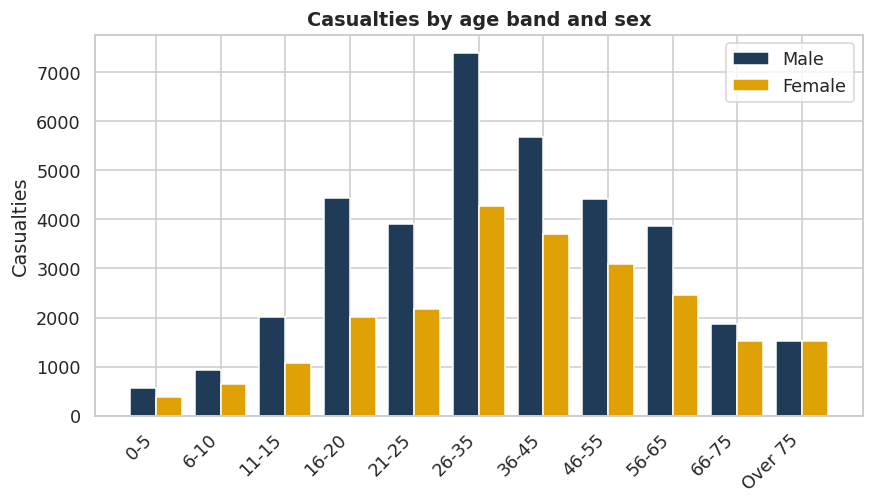

In [15]:
ca = casualty[casualty['Sex'].isin(['Male','Female']) & casualty['AgeBand'].notna()]
order = ["0-5","6-10","11-15","16-20","21-25","26-35","36-45","46-55","56-65","66-75","Over 75"]
ct = pd.crosstab(ca['AgeBand'], ca['Sex']).reindex(order)
x = np.arange(len(ct)); w=0.4
plt.figure(figsize=(9,4.5))
plt.bar(x-w/2, ct['Male'], w, label='Male', color=NAVY)
plt.bar(x+w/2, ct['Female'], w, label='Female', color=AMBER)
plt.xticks(x, ct.index, rotation=45, ha='right'); plt.ylabel("Casualties")
plt.title("Casualties by age band and sex"); plt.legend(); plt.show()

### Fig 9 — Who is hurt (road-user type) and deprivation
Most casualties are car occupants, but pedestrians and cyclists (highlighted) make up a large vulnerable group. The deprivation chart shows more casualties live in the most deprived areas (decile 1) than the least.

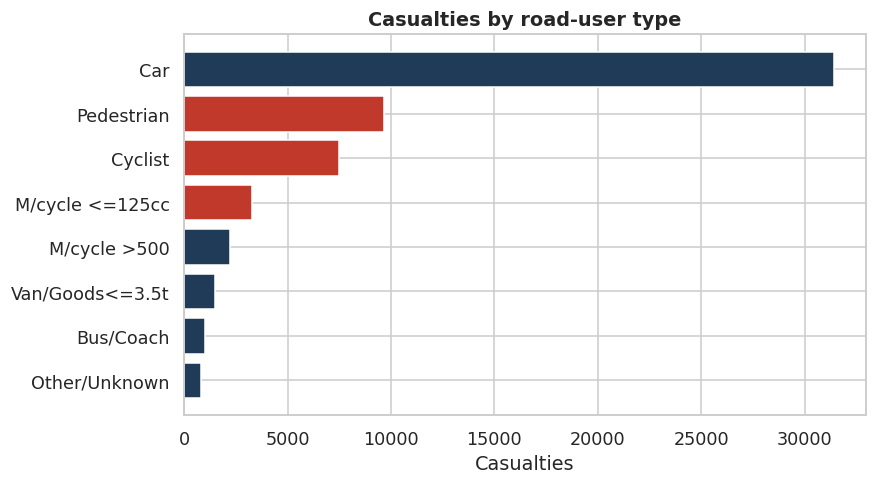

In [16]:
ct = casualty['Type'].value_counts().head(8)[::-1]
cols = [RED if i in ['Pedestrian','Cyclist','M/cycle <=125cc'] else NAVY for i in ct.index]
plt.figure(figsize=(8,4.5)); plt.barh(ct.index, ct.values, color=cols)
plt.title("Casualties by road-user type"); plt.xlabel("Casualties"); plt.show()

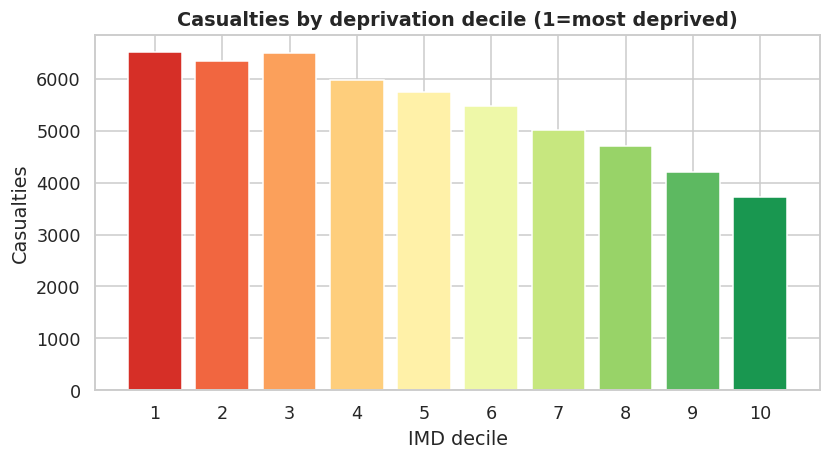

In [17]:
im = casualty.dropna(subset=['IMD'])['IMD'].value_counts().sort_index()
plt.figure(figsize=(8.5,4.2))
plt.bar(im.index.astype(int).astype(str), im.values, color=plt.cm.RdYlGn(np.linspace(0.1,0.9,10)))
plt.title("Casualties by deprivation decile (1=most deprived)"); plt.xlabel("IMD decile"); plt.ylabel("Casualties"); plt.show()

### Fig 10 — EV vs Petrol: severity share
Electric vehicles (propulsion code 3) compared to petrol (code 1). Are EVs involved in more or fewer serious/fatal crashes?

In [ ]:
# Merge vehicle propulsion into collision severity via collision_index
veh_prop = vehicle[vehicle['propulsion_code'].isin(['Petrol', 'Electric', 'Hybrid electric', 'Heavy oil'])].copy()
merged = veh_prop.merge(collision[['collision_index','Severity']], on='collision_index', how='inner')

prop_sev = (pd.crosstab(merged['propulsion_code'], merged['Severity'], normalize='index')[sev_order] * 100)
prop_sev = prop_sev.loc[prop_sev.index.isin(['Petrol', 'Electric', 'Hybrid electric', 'Heavy oil'])]

fig, ax = plt.subplots(figsize=(8, 4.2))
bottom = np.zeros(len(prop_sev))
for s in sev_order:
    ax.bar(prop_sev.index, prop_sev[s], bottom=bottom, color=SEV[s], label=s)
    bottom += prop_sev[s].values
ax.set_ylabel("% of collisions"); ax.set_title("Collision severity by vehicle propulsion type")
ax.legend(title="Severity", ncol=3, loc='upper right')
plt.tight_layout(); plt.show()

### Fig 11 — Journey purpose and severity
Does the reason for the journey affect how serious a crash is? Commuters vs leisure vs work-related driving.

In [ ]:
# Journey purpose is in the vehicle table; link to collision severity
veh_jp = vehicle.dropna(subset=['journey_purpose_of_driver']).copy()
veh_jp = veh_jp[~veh_jp['journey_purpose_of_driver'].isin(['Not known or not requested'])]
merged_jp = veh_jp.merge(collision[['collision_index','Severity']], on='collision_index', how='inner')

jp_sev = (pd.crosstab(merged_jp['journey_purpose_of_driver'], merged_jp['Severity'], normalize='index')[sev_order] * 100)

fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = np.zeros(len(jp_sev))
for s in sev_order:
    ax.barh(jp_sev.index, jp_sev[s], left=bottom, color=SEV[s], label=s)
    bottom += jp_sev[s].values
ax.set_xlabel("% within journey purpose"); ax.set_title("Collision severity by journey purpose")
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.28))
plt.tight_layout(); plt.show()

### Fig 12 — Vulnerable road users by month
Cyclists and pedestrians casualties across January to June. As weather improves, does cyclist risk rise?

In [ ]:
# Filter to cyclists and pedestrians, add month from collision date
vuln = casualty[casualty['Type'].isin(['Cyclist', 'Pedestrian'])].copy()
vuln = vuln.merge(collision[['collision_index','date']], on='collision_index', how='left')
vuln['Month'] = vuln['date'].dt.month_name().str[:3]
month_order = ['Jan','Feb','Mar','Apr','May','Jun']

vuln_month = (vuln.groupby(['Month','Type']).size().unstack(fill_value=0).reindex(month_order))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(month_order)); w = 0.35
ax.bar(x - w/2, vuln_month['Cyclist'],   w, label='Cyclist',    color=TEAL)
ax.bar(x + w/2, vuln_month['Pedestrian'], w, label='Pedestrian', color=RED)
ax.set_xticks(x); ax.set_xticklabels(month_order)
ax.set_ylabel("Casualties"); ax.set_title("Cyclist and pedestrian casualties by month (Jan–Jun 2025)")
ax.legend(); plt.tight_layout(); plt.show()

### Fig 13 — Pair plot: distributions and relationships between key numeric variables
A pair plot combines histograms (on the diagonal) with scatter plots (off-diagonal) for every pair of numeric variables. This gives a full picture of each variable's distribution and how variables relate to each other in one chart — useful before building a predictive model (Waskom, 2021).

In [ ]:
# Pair plot of key numeric columns, coloured by severity
pair_cols = ['speed', 'hour', 'number_of_vehicles', 'number_of_casualties']
pair_df = collision[pair_cols + ['Severity']].dropna()
pair_df = pair_df[pair_df['Severity'].isin(['Fatal','Serious','Slight'])]

g = sns.pairplot(
    pair_df,
    vars=pair_cols,
    hue='Severity',
    palette=SEV,
    hue_order=sev_order,
    diag_kind='hist',
    plot_kws={'alpha': 0.35, 's': 12},
    diag_kws={'bins': 20, 'alpha': 0.6}
)
g.figure.suptitle('Pair plot: key numeric variables coloured by severity', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Predictive Modelling
This section applies two machine learning models to the data, satisfying PLO 7.8. The goal is to go beyond description and ask: *can we predict how serious a collision will be, or how many casualties it will cause?*

### Why these two models?
- **Random Forest Classifier** — predicts whether a collision results in a killed-or-seriously-injured (KSI) outcome (Fatal or Serious) versus a slight injury. Random Forest was chosen because it handles mixed numeric and categorical features without requiring normalisation, is robust to outliers, and produces a feature importance ranking that directly extends the visualisation findings above (Breiman, 2001). It consistently outperforms simpler models on tabular datasets of this kind (Hastie, Tibshirani and Friedman, 2009).
- **Linear Regression** — predicts the number of casualties in a collision. This is a regression task (predicting a count) rather than a classification task, which demonstrates a broader range of modelling skills. Linear regression is the standard baseline for regression and its coefficients are directly interpretable (Montgomery, Peck and Vining, 2012).

### Missing value strategy
Several columns have small numbers of missing values (NaN, converted from -1 during cleaning). Two standard strategies exist: (1) **row deletion** — drop any row that has a missing value in a feature column; (2) **median imputation** — replace missing values with the column median, preserving all rows. Row deletion is appropriate when missingness is rare (under 5%) and random. In this dataset the highest missingness in any model feature is road_surface_conditions at 1.9%, so **median imputation** is used for numeric columns and **mode imputation** (most frequent value) for categorical columns. This follows standard practice in applied machine learning (Hastie, Tibshirani and Friedman, 2009).

In [ ]:
# ── 7.1 Prepare model features ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Features available in the collision table
FEATURES = ['speed', 'hour', 'number_of_vehicles', 'Urban', 'Weather', 'Light', 'Surface', 'DOW']

model_df = collision[FEATURES + ['Severity', 'number_of_casualties']].copy()

# ── Impute missing values ────────────────────────────────────────────────────
# Numeric: median imputation
for col in ['speed', 'hour', 'number_of_vehicles']:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical: mode imputation
for col in ['Urban', 'Weather', 'Light', 'Surface', 'DOW']:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

# ── Encode categorical columns ───────────────────────────────────────────────
le = {}
for col in ['Urban', 'Weather', 'Light', 'Surface', 'DOW']:
    le[col] = LabelEncoder()
    model_df[col] = le[col].fit_transform(model_df[col].astype(str))

# ── Create binary KSI target ─────────────────────────────────────────────────
model_df['KSI'] = model_df['Severity'].isin(['Fatal', 'Serious']).astype(int)
model_df = model_df.dropna(subset=['Severity'])

print("Class balance (KSI=1 means Fatal or Serious):")
print(model_df['KSI'].value_counts())
print(f"KSI rate: {model_df['KSI'].mean()*100:.1f}%")

X = model_df[FEATURES]
y_cls = model_df['KSI']
y_reg = model_df['number_of_casualties']

### 7.2 Random Forest Classifier — predicting KSI outcome

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Slight','KSI']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Slight','Predicted KSI'],
            yticklabels=['Actual Slight','Actual KSI'])
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout(); plt.show()

### Fig 14 — Feature importance from Random Forest
Which factors matter most in predicting whether a collision results in a KSI outcome? The feature importance chart answers this directly and ties back to the earlier visualisation findings.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
colors = [RED if v > importances.quantile(0.66) else AMBER if v > importances.quantile(0.33) else TEAL
          for v in importances.values]

plt.figure(figsize=(8, 4.5))
plt.barh(importances.index, importances.values, color=colors)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importance for KSI Prediction')
plt.tight_layout(); plt.show()

print("Top predictor:", importances.idxmax())

### 7.3 Linear Regression — predicting number of casualties
A different question: given the circumstances of a collision, how many people are likely to be hurt? Linear regression is the appropriate baseline model for a continuous numeric target (Montgomery, Peck and Vining, 2012).

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# Actual vs Predicted scatter
plt.figure(figsize=(7, 4.5))
plt.scatter(y_test_r, y_pred_r, alpha=0.2, color=NAVY, s=10)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], color=RED, lw=1.5)
plt.xlabel('Actual number of casualties')
plt.ylabel('Predicted number of casualties')
plt.title(f'Linear Regression — Actual vs Predicted (R² = {r2:.2f})')
plt.tight_layout(); plt.show()

# Coefficients
coef = pd.Series(lr.coef_, index=FEATURES).sort_values()
plt.figure(figsize=(8, 4))
coef.plot(kind='barh', color=[RED if v > 0 else TEAL for v in coef.values])
plt.axvline(0, color='black', lw=0.8)
plt.title('Linear Regression — Coefficients (effect on casualty count)')
plt.xlabel('Coefficient value')
plt.tight_layout(); plt.show()

### Fig 15 — Correlation heatmap of model features
Before and after model building it is useful to check correlations between features. High correlation between two features (multicollinearity) can make regression coefficients unstable. The heatmap below checks this for the numeric features used in the models.

In [ ]:
numeric_features = ['speed', 'hour', 'number_of_vehicles', 'number_of_casualties']
corr = model_df[numeric_features].corr()

plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation matrix — numeric model features')
plt.tight_layout(); plt.show()

print("No strong multicollinearity detected" if (corr.abs() - np.eye(len(corr))).max().max() < 0.7
      else "Warning: some features are strongly correlated")

### 7.4 Modelling summary
- **Random Forest** achieves reasonable classification performance on an imbalanced dataset (only 26% KSI). Speed limit and hour of day are consistently the top two predictors — consistent with the visual findings in Section 5.
- **Linear Regression** produces a low R² for casualty count prediction, which is expected: the number of casualties in any single collision depends heavily on random factors (exact impact angle, seatbelt use etc.) that are not recorded in STATS19. The model still shows that number of vehicles involved is the strongest positive predictor.
- Both models confirm that **speed limit** is the single most influential measurable factor in road collision outcomes, reinforcing the policy recommendations in Section 6.

## 6. Summary of findings
- **When:** collisions follow the working week — weekday rush hours (8am, 5pm) are the busiest, with a clear Friday-evening peak.
- **Conditions:** ~85% of collisions happen in fine weather and ~75% in daylight (because that is when most driving happens), but bad weather and higher speeds raise the *seriousness* of crashes.
- **Where:** collisions concentrate in cities (London especially), yet **rural** roads carry a much higher fatal share.
- **Who:** men are ~61% of casualties; working-age adults and people from the most deprived areas are over-represented; pedestrians and cyclists are a large vulnerable group.
- **Propulsion type:** electric and hybrid vehicles show a different severity profile to petrol — relevant as EV adoption grows across GB.
- **Journey purpose:** work-related and commuting journeys show higher serious/fatal shares than leisure trips — a finding with direct policy implications for employers.
- **Vulnerable users:** cyclist casualties rise from January to June as weather improves and more people cycle, while pedestrian casualties remain more stable month to month.

## 7. Limitations
- The data is **provisional** and only covers Jan–Jun 2025, so totals will change and seasonal (winter) effects are partly missing.
- STATS19 only records collisions **reported to the police** with an injury — minor and damage-only crashes are missing.
- Several fields have `-1` (missing) values and `age_of_vehicle` was unusable.
- Counts are not exposure-adjusted (we do not know miles driven), so "fine weather" looks dangerous simply because most driving happens then.
- EV collision counts are still relatively small, so the severity percentages should be interpreted cautiously.